In [1]:
import utility_functions as utils
import GLM
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import numpy.matlib
sns.set_theme()

# Estimating coupling filter from neuron 1 to neuron 2

It's a simple scenario where external stimulus (e.g. visual stimulus) affects both neuron 1 and neuron 2, and there is also a one-way coupling effect from neuron 1 to neuron 2 ($\gamma_{2,1,:}$). We don't consider self effects (i.e. $\gamma_{1,1,:}$ and $\gamma_{2,2,:}$ are all zeros) or the effect from neuron 2 to neuron 1 (i.e. $\gamma_{1,2,:}$ are all zeros).

## Creating ground truth

In [2]:
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 2000 # 5000 trials in total
Npop = 10 # ten neurons in each population
time_line = np.arange(nt)
log_lambda_baseline = np.log(0.05) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 0.1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 
# We assume stimulus is the same for every trial. 

log_lambda_neuron1 = log_lambda_baseline + log_lambda_stimulus
lambda_neuron1 = np.exp(log_lambda_neuron1)
spike_neuron1 = np.random.poisson(lam=np.matlib.repmat(lambda_neuron1[:,np.newaxis],1,ntrial), size=None)


Let's assume the synapses from neuron 1 to neuron 2 is excitatory. Spikes of neuron 1 have positive effect on neuron 2 firing rate. Note that we have 30 previous histories in the ground truth model. 

Text(0.5, 1.0, 'ground truth $\\gamma_{2,1,:}$')

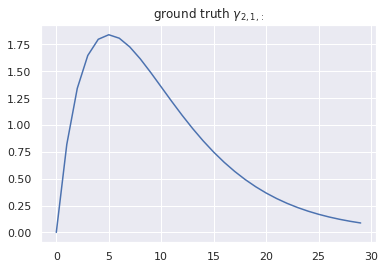

In [18]:
coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = time_line_coupling*np.exp(-time_line_coupling/5)
plt.plot(ground_truth_coupling_filter)
plt.title('ground truth $\gamma_{2,1,:}$')

In [11]:
log_lambda_coupling = GLM.conv(spike_neuron1, ground_truth_coupling_filter[:, np.newaxis])
log_lambda_coupling = log_lambda_coupling.reshape((nt, ntrial), order='F')
log_lambda_neuron2 = log_lambda_baseline + 0.5*log_lambda_stimulus[:,np.newaxis] + log_lambda_coupling
lambda_neuron2 = np.exp(log_lambda_neuron2)

In [12]:
lambda_neuron2.shape

(1000, 2000)

In [13]:
spike_neuron2 = np.random.poisson(lam=lambda_neuron2)

In [14]:
spike_neuron2.shape

(1000, 2000)

If we look at the log lambda of a given trial, we can see the firing rate of neuron 2 suddenly jump up when neuron 1 spikes. 

Text(0.5, 1.0, 'log firing rate of an example trial')

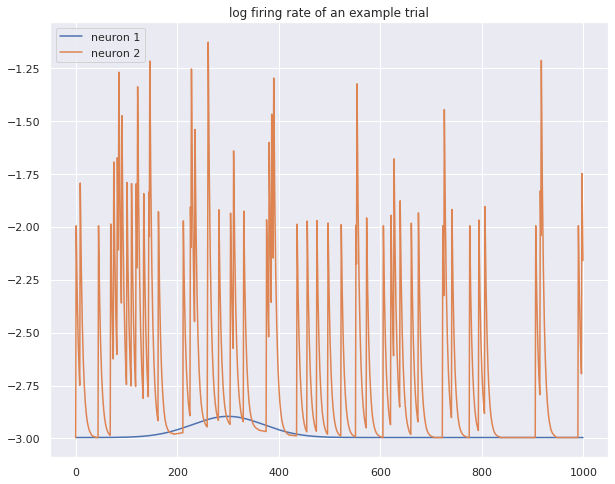

In [15]:
plt.subplots(figsize=(10,8))
plt.plot(log_lambda_neuron1, label='neuron 1')
plt.plot(log_lambda_neuron2[:,0], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

In [23]:
baseline_mat = np.vstack((log_lambda_neuron1, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = 

In [ ]:
GLM.simulate_baseline_coupling()